# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

## Question 1
#### 1.1)
* We use general linear models in analysis because they are interpretable. We use latent variable models and pass linear latent variables into activation functions because they can accommodate reasonable restrictions on outcomes. Latent linear models paired with activation functions enable these restrictions on the outcome while linear models cannot, giving them an advantage.
#### 1.2)
* Binary and categorical cross entropy are effective loss functions for fitting logistic regression models because both work to maximize log likelihood and minimize binary/categorical cross entropy, effectively producing a maximum likelihood estimation to better fit logistic regression models.
#### 1.3)
* False because logistic regression is only a linear model if A(L) = L, if this isn't the case then it's a non-linear model.
#### 1.4)
* False because you can "round" a logistic regression's output to 0 or 1, enabling it to be used for classification.
#### 1.5)
* The coefficient in a logistic regression does not represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable because in non-linear models a change in x won't impact changes in y in proportion to b anymore. 
#### 1.6)
* False because logistic regression uses a latent index over a carefully engineered feature space to predict probability, making feature engineering necessary despite it being non-linear.
#### 1.7) 
* False because logistic regression is an improvement over the usual linear model when the outcome is binary, but linear models are used when the outcome is numeric, so each model is used for different use cases.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


Debtor 0.5306254197595265
Tuition fees up to date -2.556542432760276
Scholarship holder -1.2274415222724468
Age at enrollment 0.049925412464890406


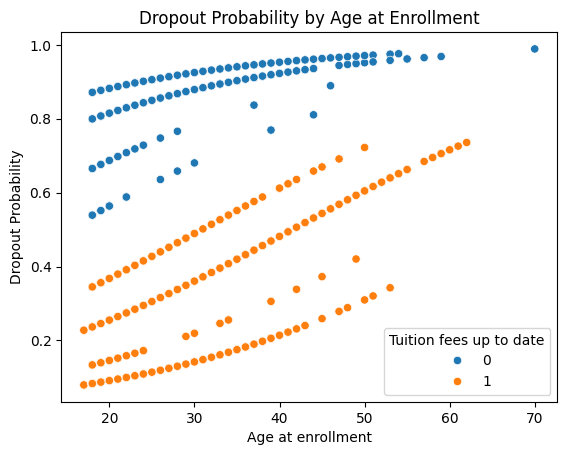

0.6125849339806471
0.7619801084990958


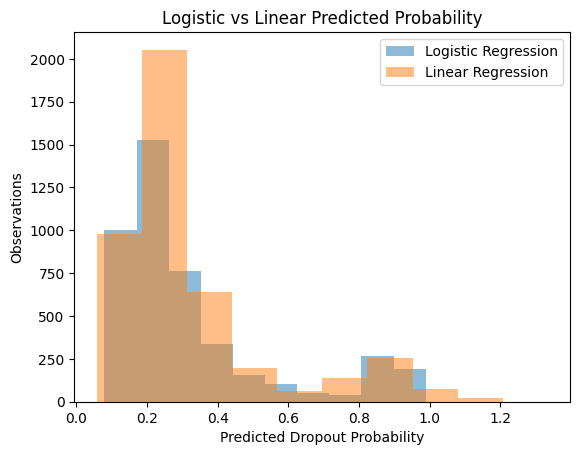

Target    Dropout  Enrolled  Graduate
row_0                                
Dropout      1054       280       146
Graduate      367       514      2063
accuracy 0.35443037974683544
compare 0.7045660036166366
[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 ...
 [0.07193813 0.14064437 0.78741751]
 [0.18422683 0.21266883 0.60310434]
 [0.11780804 0.1769832  0.70520876]]


In [5]:
import pandas as pd 
from sklearn.linear_model import LogisticRegression, LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#2.1 
collegeData = pd.read_csv("./data/data.csv", delimiter = ";") 
columnFilter = ["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment", "Curricular units 1st sem (approved)", "Target"] 
collegeData = collegeData[columnFilter]
collegeData["Dropout"] = collegeData["Target"] == "Dropout"
collegeData = collegeData.dropna()

#2.2) 
columnData = collegeData[["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]] 
dropoutData = collegeData["Dropout"] 
logisticRegression = LogisticRegression() 
logisticRegression.fit(columnData, dropoutData) 
for i in range(len(columnData.columns)):
    print(columnData.columns[i], logisticRegression.coef_[0][i])

#2.3)
dropoutProbability = logisticRegression.predict_proba(columnData) 
dropoutProbabilityArray = [] 
for i in range(len(dropoutProbability)):
    dropoutProbabilityArray.append(dropoutProbability[i][1])
collegeData["Dropout Probability"] = dropoutProbabilityArray 
sns.scatterplot(x = collegeData["Age at enrollment"], y = collegeData["Dropout Probability"], hue = collegeData["Tuition fees up to date"]) 
plt.ylabel("Dropout Probability") 
plt.xlabel("Age at enrollment") 
plt.title("Dropout Probability by Age at Enrollment") 
plt.show()
notUpToDateAverage = collegeData[collegeData["Tuition fees up to date"] == 0]["Dropout Probability"].mean()
upToDateAverage = collegeData[collegeData["Tuition fees up to date"] == 1]["Dropout Probability"].mean() 
print(notUpToDateAverage - upToDateAverage)

#2.4)
classVariable = pd.Series(logisticRegression.predict(columnData))
tabVariable = pd.crosstab(classVariable, dropoutData) 
accuracyVariable = np.trace(tabVariable) / len(classVariable)
print(accuracyVariable)

#2.5
linearRegression = LinearRegression() 
linearRegression.fit(columnData, dropoutData) 
linearDropoutProbability = linearRegression.predict(columnData) 
plt.hist(x = dropoutProbabilityArray, alpha = 0.5, label = "Logistic Regression") 
plt.hist(x = linearDropoutProbability, alpha = 0.5, label = "Linear Regression") 
plt.ylabel("Observations")
plt.xlabel("Predicted Dropout Probability") 
plt.title("Logistic vs Linear Predicted Probability") 
plt.legend() 
plt.show()

#2.7
multinomialData = collegeData[["Debtor", "Tuition fees up to date", "Curricular units 1st sem (approved)"]] 
targetVariable = collegeData["Target"] 
multinomialLogisticRegression = LogisticRegression()
multinomialLogisticRegression.fit(multinomialData, targetVariable)
classVariable = pd.Series(multinomialLogisticRegression.predict(multinomialData)) 
tabVariable = pd.crosstab(classVariable, targetVariable) 
accuracyVariable = np.trace(tabVariable) / len(classVariable)
print(tabVariable)
print("accuracy", accuracyVariable)
print("compare", np.mean(classVariable == targetVariable))
probaPredictionValue = multinomialLogisticRegression.predict_proba(multinomialData) 
print(probaPredictionValue)



## Question 2 
#### 2.1)
* I handled missing values by using the dropna() function on the college data.
#### 2.2) 
* The "Debtor" and "Age at enrollment" variables predict a higher dropout probability while the "Tuition fees up to date" and "Scholarship holder" variables predict a lower dropout probability. Being up to date on tuition does seem to reduce dropout risk.
#### 2.3) 
* Being up to date on tuition appears to reduce dropout probability the most across all ages somewhat evenly, with it being slightly larger at older ages. On average, being up to date on tuition changed the predicted probability of dropout by 0.61. 
#### 2.4) 
* The accuracy is 0.76.
#### 2.5) 
* The logistic regression keeps the dropout probability values within the valid 0-1 range while the linear regression has some values that extend beyond this range, resulting in the logistic regression having better performance for this case due to its spread of values staying within the valid range.
#### 2.6) 
* Based on my above work, the students most at-risk of dropping out are students with higher age of enrollment, students that don't hold scholarships, students not up to date on tuition, and students with debt. Some interventions I can imagine that would help at-risk students stay enrolled are the development of a strong student counseling and support framework, the implementation of stronger financial aid and scholarship programs, and the creation of an easy to use and flexible online student financial center. 
#### 2.7)
* The confusion matrix shows that graduate had the greatest number of correct predictions and dropout had the second greatest number while enrolled had poor performance, lacking a row entirely. The confusion matrix has an accuracy of 0.35. My hard classification does not predict every class, it doesn't predict the enrolled class. My predicted probabilities do predict every class, containing three values each for Dropout, Enrolled, and Graduate.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

Bilirubin -0.35142389843544086
S -0.4506766325523586
Y -1.6110491833168032
Placebo 0.23122512449170887


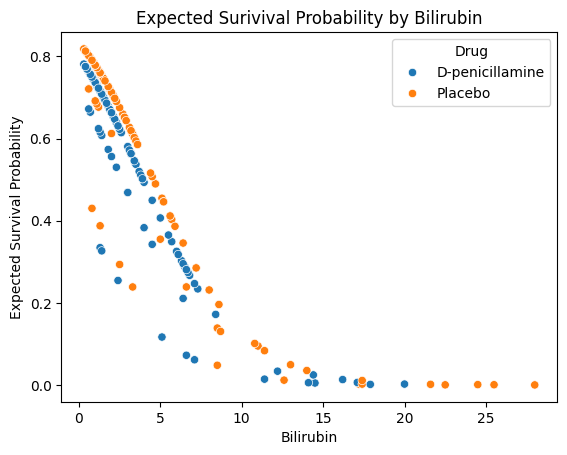

0.018848501038509102
Alive  False  True 
row_0              
False     59     16
True      66    171
accuracy 1:  0.7371794871794872
accuracy 2:  0.7371794871794872


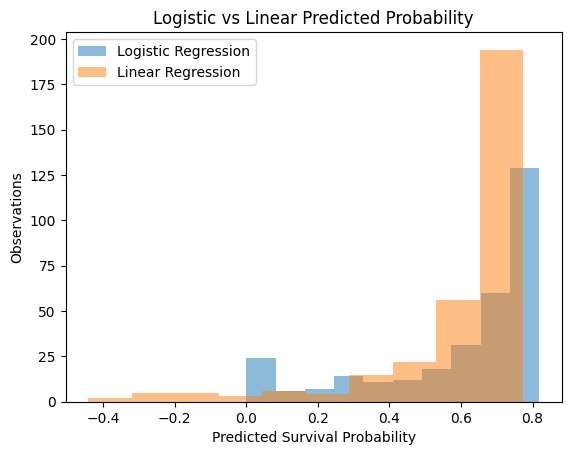

Stage  1.0  2.0  3.0  4.0
row_0                    
3.0     16   63  105   79
4.0      0    4   15   30
accuracy:  0.4326923076923077
[[1.28550372e-05 3.25351316e-02 1.43611431e-01 8.23840583e-01]
 [7.23937578e-02 2.51555267e-01 3.97519699e-01 2.78531276e-01]
 [2.92626485e-02 1.81530850e-01 3.95694470e-01 3.93512032e-01]
 ...
 [5.23225350e-02 2.46351600e-01 4.07443845e-01 2.93882020e-01]
 [4.43645995e-02 2.43147794e-01 4.11411355e-01 3.01076251e-01]
 [3.56079503e-03 1.81091914e-01 4.27967363e-01 3.87379928e-01]]


In [ ]:
#3.1
cirrhosisData = pd.read_csv("./data/cirrhosis.csv")
filterColumns = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
cirrhosisData = cirrhosisData[filterColumns]
cirrhosisData = cirrhosisData.dropna()

#3.2
cirrhosisData["Alive"] = cirrhosisData["Status"] != "D"
regressionVariables = cirrhosisData[["Edema", "Drug", "Bilirubin"]]
newEdema = pd.get_dummies(cirrhosisData["Edema"], drop_first = True)
newDrug = pd.get_dummies(cirrhosisData["Drug"], drop_first = True)
regressionVariables = pd.concat([cirrhosisData[["Bilirubin"]], newEdema, newDrug], axis = 1)
aliveVariable = cirrhosisData["Alive"]
logisticRegression = LogisticRegression()
logisticRegression.fit(regressionVariables, aliveVariable)
for i in range(len(regressionVariables.columns)):
    print(regressionVariables.columns[i], logisticRegression.coef_[0][i])

#3.3
expectedSurvival = logisticRegression.predict_proba(regressionVariables)
expectedSurvivalArray = []
for i in range(len(expectedSurvival)):
    expectedSurvivalArray.append(expectedSurvival[i][1])
cirrhosisData["Expected Survival"] = expectedSurvivalArray 
sns.scatterplot(x = cirrhosisData["Bilirubin"], y = cirrhosisData["Expected Survival"], hue = cirrhosisData["Drug"])
plt.ylabel("Expected Survival Probability") 
plt.xlabel("Bilirubin") 
plt.title("Expected Surivival Probability by Bilirubin") 
plt.show()
takeDrug = cirrhosisData[cirrhosisData["Drug"] == "D-penicillamine"]["Expected Survival"].mean()
takePlacebo = cirrhosisData[cirrhosisData["Drug"] == "Placebo"]["Expected Survival"].mean()
print(takePlacebo - takeDrug)

#3.4
classVariable = pd.Series(logisticRegression.predict(regressionVariables))
tabVariable = pd.crosstab(classVariable, aliveVariable) 
accuracyVariable = np.trace(tabVariable) / len(classVariable) 
print(tabVariable)
print("accuracy: ", accuracyVariable)

#3.5
linearRegression = LinearRegression() 
linearRegression.fit(regressionVariables, aliveVariable) 
linearExpectedSurvival = linearRegression.predict(regressionVariables) 
plt.hist(x = expectedSurvivalArray, alpha = 0.5, label = "Logistic Regression") 
plt.hist(x = linearExpectedSurvival, alpha = 0.5, label = "Linear Regression") 
plt.ylabel("Observations") 
plt.xlabel("Predicted Survival Probability") 
plt.title("Logistic vs Linear Predicted Probability") 
plt.legend() 
plt.show()

#3.6
newRegressionVariables = pd.concat([cirrhosisData[["Bilirubin"]], newEdema], axis = 1)
stageVariable = cirrhosisData["Stage"] 
secondLogisticRegression = LogisticRegression() 
secondLogisticRegression.fit(newRegressionVariables, stageVariable) 
classVariable = pd.Series(secondLogisticRegression.predict(newRegressionVariables)) 
tabVariable = pd.crosstab(classVariable, stageVariable) 
accuracyVariable = np.trace(tabVariable) / len(classVariable)
print(tabVariable)
print("accuracy 1: ", accuracyVariable) 
print("accuracy 2: ", np.mean(classVariable == stageVariable))
probaValue = secondLogisticRegression.predict_proba(newRegressionVariables) 
print(probaValue)

## Question 3
#### 3.1)
* I handled missing values using the dropna() function on the cirrhosis data.
#### 3.2)
* The drug does not improve survival probability seen through the placebo's 0.23 coefficient. Higher bilirubin predicts a lower survival rate while lower bilirubin predicts a higher survival rate seen through bilirubin's -0.35 coefficient. Survival rate varies with edema by decreasing for S (-0.45 coefficient) and decreasing even more for Y (-1.61 coefficient). 
#### 3.3)
* Based on the scatterplot there are no consistent values of bilirubin where the drug appears to increase patient survival rate. On average, patients who take the drug (D-penicillamine) decrease their rate of survival by 0.019 compared to patients who take the placebo.
#### 3.4)
* The accuracy is 0.74. 
#### 3.5) 
* The linear regression has values that extend below 0.0 which is out of the valid 0.0 to 1.0 range. The logistic regression keeps all values within this valid range, meaning its performance is better than the linear regression's because it keeps all values within a valid range.
#### 3.6)
* The confusion matrix only shows predictions for stages 3.0 and 4.0, lacking predictions for 1.0 and 2.0 entirely. Its accuracy 0.064 which is extremely low and illustrated in its lack of predictions for stages 1.0 and 2.0. My hard classification does not predict every class, missing classes 1.0 and 2.0. My predicted probabilities do predict every class, seen in each prediction list containing four numbers which each represent a stage.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

## Question 4
#### 4.0)
* The coefficients of a logistic regression are the numbers associated with each input into the model. You interpret their values by associating a positive value with higher likelihood and a negative value with lower likelihood.
#### 4.1)
* The derivative is: $$\frac{\partial \hat{y}}{\partial x_k} = b_k$$ 
* For a 1 unit change in my feature the prediction changes by $b_k$.
#### 4.2)
* The derivative is: $$\frac{\partial \hat{p}_i}{\partial x_k} = \hat{p}_i(1 - \hat{p}_i)b_k$$
* As $x$ changes my answer does change. It's similar to part 1 because the coefficients for each both still influence the models and $b_k$ is still present. It's different because linear just considers $b_k$ while logistic considers $\hat{p}_i(1 - \hat{p}_i)$ along with $b_k$, so the impact scales with more than just $b_k$. For values of $\hat{p}_i$ near 0.5 is the coefficient itself (times 4) a roughly good estimate of how a change in $x_k$ affects the prediction.
#### 4.3)
* A one unit change in $x_k$ affects the log odds ratio by $b_k$.
